# Homework 4, Part 1: Φτιάχνουμε ένα pandas cheat sheet

**Χρησιμοποιούμε το αρχείο `animals.csv` για να απαντήσουμε στις παρακάτω ερωτήσεις.** Το notebook αυτό θα μπορείτε να το χρησιμοποιήσετε μελλοντικά.

## 0) Setup

Κάντε Import pandas **με την σωστή ονομασία** και εισάγετε την `matplotlib` για να εμφανίζονται τα γραφικά στο notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1) Διαβάστε το csv


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datajour-gr/Data_journalism/refs/heads/master/week4/animals.csv")

## 2) Τσεκάρετε τα δεδομένα

Τυπώστε τον αριθμό γραμμών και στηλών καθώς και το όνομα και τον τύπο της κάθε στήλης (column).

In [3]:
df.shape

(6, 3)

In [6]:
df.dtypes

,0
animal,object
name,object
length,int64


## 3) Τυπώστε τα πρώτα 3 ζώα.

Γνωρίζουμε πως να εμφανίσουμε τα πρώτα 5, αλλά όχι τα πρώτα 3.

In [7]:
df.head(3)

,animal,name,length
0,cat,Anne,35
1,cat,Bob,45
2,dog,Egglesburg,65


## 4) Σορτάρετε τα ζωά για να τυπώσετε τα 3 μακρύτερα

> **Συμβουλή:** Χρησιμοποιήστε το `.head()` μετά το sort!

In [9]:
df.sort_values(by ='length', ascending=False).head(3)


,animal,name,length
2,dog,Egglesburg,65
3,dog,Devon,50
1,cat,Bob,45


## 5) Πάρτε το mean και το standard deviation από τα μήκη των ζώων.

In [10]:
import statistics

In [22]:
print(df['length']. mean())


43.666666666666664


In [23]:
print(df['length'].std())

12.516655570345725


## 6) Πόσες γάτες και πόσοι σκύλοι υπάρχουν στα δεδομένα?


In [27]:
df['animal'].value_counts()

,count
animal,
cat,3
dog,3


## 7) Τυπώστε μόνο τους σκύλους

> **Συμβουλή:** Είναι πιο εύκολο να τυπώσετε πρώτα τη λίστα με τα `True`/`False` και μετά βάλτε την εντολή μέσα σε ένα ακόμα `df[]`.

In [28]:
df['animal'] == 'dog'

,animal
0,False
1,False
2,True
3,True
4,False
5,True


In [30]:
df[df['animal'] == 'dog']

,animal,name,length
2,dog,Egglesburg,65
3,dog,Devon,50
5,dog,Fontaine,35


## 8) Τωπώστε τα ζώα με μήκος μεγαλύτερο από 40cm

In [32]:
df[df['length'] > 40]

,animal,name,length
1,cat,Bob,45
2,dog,Egglesburg,65
3,dog,Devon,50


## 9) `length` είναι το μέγεθος των ζώων σε εκατοστά. Φτιάξτε μια νέα στήλη που να λέγεται  `meters` και αντιστοιχεί στο μέγεθος των ζώων σε μέτρα.

In [51]:
length_meters = df['length'] / 100
display(length_meters)

,length
0,0.35
1,0.45
2,0.65
3,0.50
4,0.32
5,0.35


## 10) Σώστε τις γάτες σε μια νέα μεταβλητή που να λέγεται  `cats` και σε μια άλλη τους σκύλους `dogs`.

In [67]:
df_cats = df[df['animal'] == 'cat']
display(df_cats)


,animal,name,length,length_meters
0,cat,Anne,35,0.35
1,cat,Bob,45,0.45
4,cat,Charlie,32,0.32


In [70]:
df_dogs = df[df['animal'] == 'dog']
display(df_dogs)

,animal,name,length,length_meters
2,dog,Egglesburg,65,0.65
3,dog,Devon,50,0.50
5,dog,Fontaine,35,0.35


## 11) Τυπώστε όλα τα ζώα που είναι γάτες και το μήκος τους είναι πάνω από 12 εκατοστά

Πρώτα κάντε το χρησιμοποιώντας την μεταβλητή `cats` και μετά ξανά σε όλο το `df`.

> **Συμβουλή:** Για πολλαπλά conditions, χρησιμοποιήστε `df[(one condition) & (another condition)]`

In [71]:
df_cats[df_cats['length'] > 12]

,animal,name,length,length_meters
0,cat,Anne,35,0.35
1,cat,Bob,45,0.45
4,cat,Charlie,32,0.32


In [63]:
df[(df['animal'] == 'cat') & (df['length'] > 12)]

,animal,name,length,length_meters
0,cat,Anne,35,0.35
1,cat,Bob,45,0.45
4,cat,Charlie,32,0.32


## 12) Ποιο είναι το μέσο (mean) μήκος της γάτας και ποιο του σκύλου?

In [83]:
print(round(df_cats['length'].mean()))

37


In [84]:
print(round(df_dogs['length'].mean()))

50


## 13) Αν δεν το κάνατε ήδη χρησιμοποιήστε το `groupby` για να ξανατυπώσετε το #12

In [81]:
round(df.groupby('animal')['length'].mean())

,length
animal,
cat,37.0
dog,50.0


## 14) Φτιάξτε ένα ιστόγραμμα (histogram) με τα μήκη των σκύλων.

Δεν γίνεται με χρήση του `plot()`. Αναζητήστε τη λύση στο ίντερνετ!


<Axes: ylabel='Frequency'>

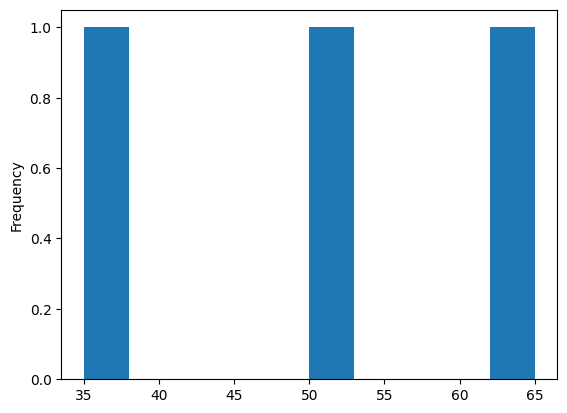

In [88]:
df_dogs['length'].plot(kind='hist', bins=10)

## 15) Φτιάξτε ένα οριζόντιο γράφημα με τα μήκη των ζώων και με το όνομά τους στο label

> **Συμβουλή:** Δεν είναι με `df['length'].plot()`, γιατί χρειάζεται δύο στήλες.

> **Συμβουλή:** Μπορείτε να αλλάξετε το μέγεθος του γραφήματος με `figsize=(2,15)`

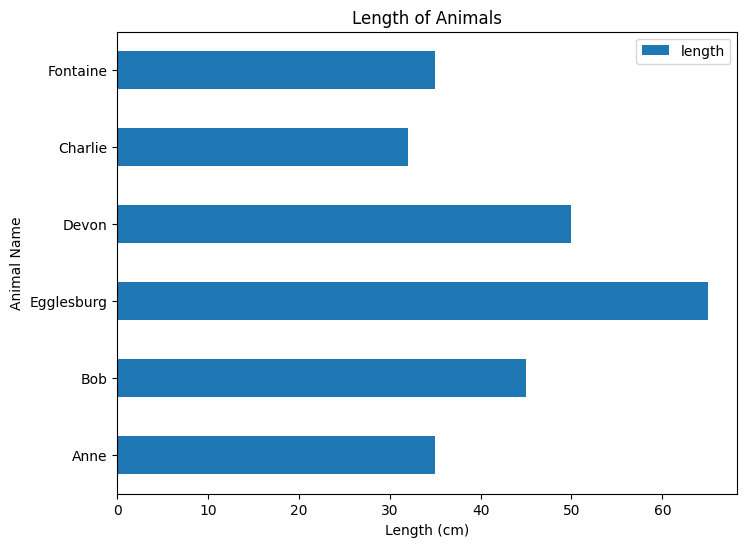

In [100]:
ax = df.plot(x='name', y='length', kind='barh', figsize=(8,6))
ax.set_xlabel('Length (cm)')
ax.set_ylabel('Animal Name')
plt.title('Length of Animals')
plt.show()

## 16) Φτιάξτε ένα σορταρισμένο οριζόντιο γράφημα με τις γάτες και οι μακρύτερες να βρίσκονται στην κορυφή.

In [111]:
df_cats_sorted = df_cats.sort_values(by='length', ascending=False)
display(df_cats_sorted)

,animal,name,length,length_meters
1,cat,Bob,45,0.45
0,cat,Anne,35,0.35
4,cat,Charlie,32,0.32


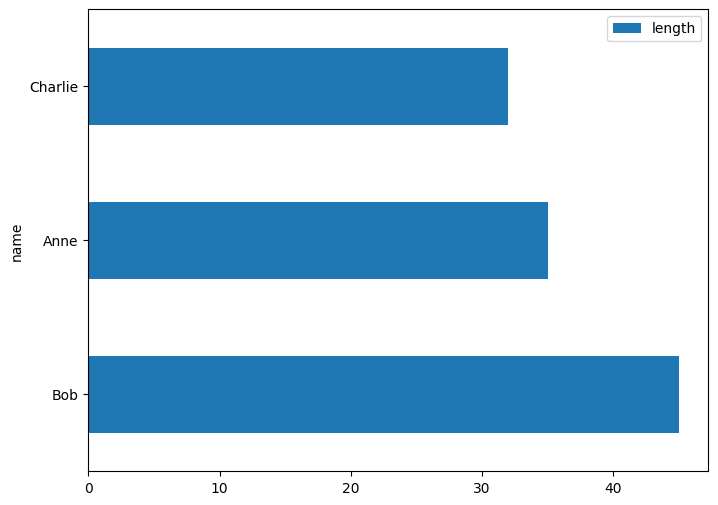

In [113]:
ax = df_cats_sorted.plot(x='name', y='length', kind='barh', figsize=(8,6))